INSTALL LIBRARIES

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

LOAD DATASET

In [4]:
df = pd.read_csv(
    "fake_job_postings.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (14456, 18)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                   

DATASET DISTRIBUTION

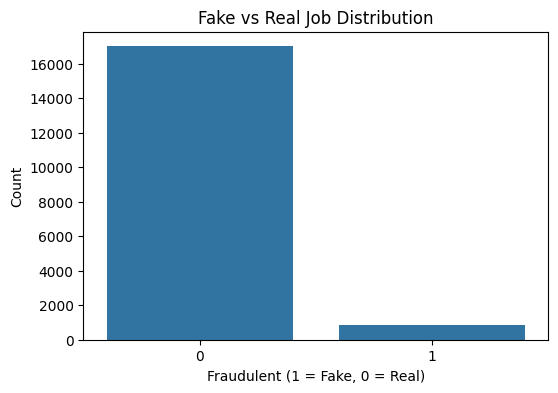

In [23]:


plt.figure(figsize=(6,4))

sns.countplot(x=df["fraudulent"])

plt.title("Fake vs Real Job Distribution")
plt.xlabel("Fraudulent (1 = Fake, 0 = Real)")
plt.ylabel("Count")

plt.show()

 CHECK MISSING VALUES

In [5]:
df = pd.read_csv("fake_job_postings.csv")

print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (17880, 18)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                   

HANDLE MISSING VALUES

In [7]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_columns:
    df[col] = df[col].fillna("")

 COMBINE TEXT COLUMNS

In [8]:
df["text"] = (
    df["title"] + " " +
    df["company_profile"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

X = df["text"]
y = df["fraudulent"]

TRAIN TEST SPLIT

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (14304,)
Testing size: (3576,)


TF-IDF FEATURE EXTRACTION

In [10]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (14304, 5000)


 MODEL 1 : LOGISTIC REGRESSION

In [11]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

TOP SCAM WORDS

In [20]:


feature_names = vectorizer.get_feature_names_out()

coefs = log_model.coef_[0]

top_fake_words = sorted(
    zip(coefs, feature_names),
    reverse=True
)[:20]

print("\nTop Words Indicating Fake Jobs:\n")

for score, word in top_fake_words:
    print(word, ":", round(score,3))


Top Words Indicating Fake Jobs:

link : 5.621
aptitude : 3.846
earn : 3.801
data entry : 3.681
money : 3.428
high school : 3.413
000 : 3.276
oil gas : 3.259
cash : 3.073
engineering : 2.992
subsea : 2.982
clerk : 2.971
offshore : 2.902
work home : 2.787
financing : 2.735
accountant : 2.649
hospital : 2.619
entry : 2.528
gas : 2.501
oil : 2.484


MODEL 2 : ADVANCED MODEL (SVM)


===== Logistic Regression Results =====
Accuracy: 0.9704

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.64      0.90      0.75       173

    accuracy                           0.97      3576
   macro avg       0.82      0.94      0.86      3576
weighted avg       0.98      0.97      0.97      3576



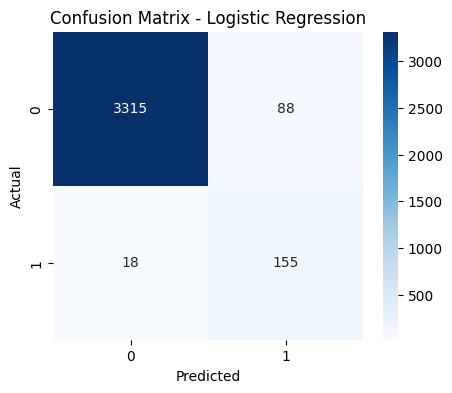

AUC Score: 0.9831


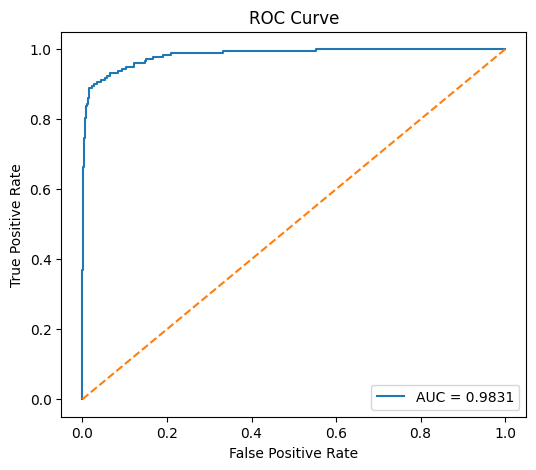

In [12]:
print("\n===== Logistic Regression Results =====")

y_pred = log_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# AUC & ROC
y_probs = log_model.predict_proba(X_test_tfidf)[:,1]

auc = roc_auc_score(y_test, y_probs)
print("AUC Score:", round(auc,4))

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


EVALUATION (SVM MODEL)

In [14]:
svm_model = LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

print("\n===== SVM Model Results =====")

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))


===== SVM Model Results =====
Accuracy: 0.9812639821029083

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.79      0.84      0.81       173

    accuracy                           0.98      3576
   macro avg       0.89      0.91      0.90      3576
weighted avg       0.98      0.98      0.98      3576



MODEL COMPARISON

In [19]:

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

models = {
    "Logistic Regression": log_model,
    "SVM": svm_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print("\nModel Comparison:\n")
print(results_df)


Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.970358   0.637860  0.895954  0.745192
1                  SVM  0.981264   0.788043  0.838150  0.812325


PREDICTION FUNCTION

In [21]:


def predict_job(text):

    text_vec = vectorizer.transform([text])

    prob = log_model.predict_proba(text_vec)[0]

    fake_prob = prob[1]
    real_prob = prob[0]

    print("\nPrediction Result\n")

    if fake_prob > real_prob:
        print("⚠ FAKE Job")
        print("Scam Probability:", round(fake_prob*100,2), "%")
    else:
        print("✅ REAL Job")
        print("Authenticity Probability:", round(real_prob*100,2), "%")

TEST SAMPLE JOB

In [22]:
sample_job = """
Software Developer – Full Time

We are looking for a skilled Software Developer to join our engineering team.
Candidates must have experience in Java, Spring Boot, and SQL databases.
This is a full-time role with competitive salary and company benefits.
"""

predict_job(sample_job)


Prediction Result

✅ REAL Job
Authenticity Probability: 79.47 %


 SAVE MODEL

In [18]:
joblib.dump(log_model, "job_scam_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model Saved Successfully")

Model Saved Successfully
